# Experimental validation of virtual gene knockdown
This tutorial examines the Shen B03018A2 spatial CRISPR dataset (Fig. 5I–K).
- **Whole-slice screen:** the 14-gene screen is loaded from the original result tables. The 96 shared mSafe controls and gene-level paired test are recalculated.
- **Local virtual knockout:** the fixed Sh3gl2 pair 4 is calculated from the unmodified 1,334-cell ROI: fit Stage 2 for 100 epochs, knock out Sh3gl2 in one mSafe source, then run frozen inference. The Linear comparator is fitted from its training input.
The ROI, matched cells, and model weights follow the figure's source analysis. HVG tokenization uses `hvg_log1p=True`. Figures are written to `tutorial/figures/fig5_experimental_ko`.
The Linear comparator follows the original manuscript analysis: its training matrix holds out Clu and includes Sh3gl2. This is the original single-case comparator, not a Sh3gl2-held-out evaluation.
Run from a fresh bb_env kernel. The float32 Linear calculation retains the original default BLAS environment.


In [1]:
from pathlib import Path
import sys, os
# Retain the original BLAS environment for the float32 Linear fit.
for variable in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS'):
    os.environ.pop(variable, None)
ROOT = Path("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main")
TUTORIAL = ROOT / "tutorial"
FRAMEWORK = TUTORIAL / "_framework/BrainBeacon"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(FRAMEWORK))
from brainbeacon.configs.config import DEFAULT_PATHS
DEFAULT_PATHS.update({
    "BASE_DIR": str(ROOT), "PRIOR_DIR": str(ROOT / "prior_knowledge"),
    "PRETRAIN_DIR": str(ROOT / "pretrained"),
    "GENE_DICT_PATH": str(ROOT / "prior_knowledge/gene_dict.h5ad"),
    "GENE_LOOKUP_DIR": str(ROOT / "prior_knowledge/gene_lookup"),
    "ESM_EMBED_PATH": str(ROOT / "prior_knowledge/esm2_embeddings_d5120.pt"),
})

## 1. Compare the whole-slice 14-gene screen with experimental results

In [2]:
from pathlib import Path
import json
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import dendrogram, dendrogram, fcluster, leaves_list, linkage, optimal_leaf_ordering
from scipy.spatial.distance import pdist
from scipy.stats import gaussian_kde, wasserstein_distance, wilcoxon
from sklearn.metrics import silhouette_score
from IPython.display import display
ROOT = Path('/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main')
RESULT_ROOT = ROOT / 'perturb_analysis/shen_fullslice_all_msafe_target_only'
SLICE_ID = 'GSM9659883_B03018A2'
SLICE_DIR = RESULT_ROOT / SLICE_ID
PANORAMA_DIR = RESULT_ROOT / 'cell_level_panorama'
PREVIOUS_DIR = RESULT_ROOT / 'B03018A2_msafe_ge3_notebook'
OUTPUT_DIR = TUTORIAL / 'outputs/fig5_experimental_ko/screen'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ATTEMPT_PATH = TUTORIAL / 'data/05_experimental_ko/all_attempted_slice_gene_results.tsv'
CELL_PATH = TUTORIAL / 'data/05_experimental_ko/shen_fullslice_cell_gene_alignment.tsv.gz'
PANEL_PATH = SLICE_DIR / 'model_panel.h5ad'
RESULT_PATH = TUTORIAL / 'data/05_experimental_ko/B03018A2_mSafe_ge3_14gene_results.tsv'
MIN_WET_CELLS = 20
MIN_POSITIVE_MSAFE_CELLS = 3
EXPECTED_GENES = ['Cfap410', 'Clu', 'Dpp6', 'Fasn', 'Flcn', 'Gfap', 'Lrrk2', 'Ndufaf2', 'Rbfox3', 'Rraga', 'Sh3gl2', 'Srf', 'Stk39', 'Tbk1']
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
pd.set_option('display.max_columns', 100)
print('Output directory:', OUTPUT_DIR)

Output directory: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/screen


In [3]:
attempts = pd.read_csv(ATTEMPT_PATH, sep='\t')
audit = attempts.loc[attempts['slice_id'].eq(SLICE_ID) & attempts['status'].eq('complete') & attempts['bb_alignment'].notna() & attempts['linear_alignment'].notna()].copy()
audit = audit.sort_values('target_gene').reset_index(drop=True)
audit['positive_msafe_cells'] = np.rint(audit['n_msafe'] * audit['msafe_target_positive_fraction']).astype(int)
audit['selected_ge3'] = audit['n_wet'].ge(MIN_WET_CELLS) & audit['positive_msafe_cells'].ge(MIN_POSITIVE_MSAFE_CELLS)
selected = audit.loc[audit['selected_ge3']].copy()
frozen_results = pd.read_csv(RESULT_PATH, sep='\t')
frozen_results = frozen_results.set_index('target_gene').loc[EXPECTED_GENES]
selected = selected.set_index('target_gene')
selected = selected.loc[EXPECTED_GENES].reset_index()
group_test = wilcoxon(selected['bb_alignment'], selected['linear_alignment'], alternative='greater', zero_method='wilcox', method='exact')
cell_values = pd.read_csv(CELL_PATH, sep='\t')
selected_cells = cell_values.loc[cell_values['slice_id'].eq(SLICE_ID) & cell_values['target_gene'].isin(EXPECTED_GENES)].copy()
panel = ad.read_h5ad(PANEL_PATH, backed='r')
coords = np.asarray(panel.obsm['spatial'], dtype=float)
obs = panel.obs.copy()
obs_names = obs.index.astype(str)
obs_lookup = pd.Series(np.arange(panel.n_obs), index=obs_names)
guide_label = obs['guide_label'].astype(str)
msafe_mask = guide_label.str.lower().eq('sgrna_msafe').to_numpy()
msafe_indices = np.flatnonzero(msafe_mask)
msafe_names = obs_names[msafe_indices].tolist()
gene_symbols = panel.var['gene_symbol'].astype(str)
alignment_matrix = selected_cells.pivot(index='source_obs_name', columns='target_gene', values='bb_cell_alignment').reindex(index=msafe_names, columns=EXPECTED_GENES)
target_columns = []
for gene in EXPECTED_GENES:
    found = np.flatnonzero(gene_symbols.eq(gene).to_numpy())
    target_columns.append(int(found[0]))
expression_block = panel[msafe_indices, target_columns].X
if sparse.issparse(expression_block):
    expression_block = expression_block.toarray()
expression_block = np.asarray(expression_block)
detection_matrix = expression_block > 0
direct_counts = detection_matrix.sum(axis=0).astype(int)
expected_counts = selected.set_index('target_gene').loc[EXPECTED_GENES, 'positive_msafe_cells'].to_numpy(int)
source_summary = pd.DataFrame({'source_obs_name': msafe_names, 'x': coords[msafe_indices, 0], 'y': coords[msafe_indices, 1], 'median_bb_alignment': alignment_matrix.median(axis=1, skipna=True).to_numpy(), 'positive_alignment_fraction': alignment_matrix.gt(0).sum(axis=1).to_numpy() / alignment_matrix.notna().sum(axis=1).clip(lower=1).to_numpy(), 'finite_gene_count': alignment_matrix.notna().sum(axis=1).to_numpy(int), 'detectable_target_count': detection_matrix.sum(axis=1).astype(int)})
source_summary.to_csv(OUTPUT_DIR / 'B03018A2_96_mSafe_aggregate_spatial_values.tsv', sep='\t', index=False)
display(selected[['target_gene', 'positive_msafe_cells', 'n_wet', 'bb_alignment', 'linear_alignment', 'bb_minus_linear']].style.format({'bb_alignment': '{:.3f}', 'linear_alignment': '{:.3f}', 'bb_minus_linear': '{:+.3f}'}))
print(f"Selected genes: {len(selected)}; BB > Linear: {(selected['bb_minus_linear'] > 0).sum()}/14; exact one-sided p={group_test.pvalue:.8f}")

,target_gene,positive_msafe_cells,n_wet,bb_alignment,linear_alignment,bb_minus_linear
0,Cfap410,7,118,0.784,0.032,+0.751
1,Clu,82,419,0.708,0.045,+0.664
2,Dpp6,14,74,0.203,0.052,+0.151
3,Fasn,22,413,-0.176,-0.492,+0.315
4,Flcn,3,178,0.362,-0.040,+0.402
5,Gfap,14,161,0.613,0.530,+0.083
6,Lrrk2,3,43,-0.613,-0.260,-0.354
7,Ndufaf2,14,116,0.705,-0.048,+0.753
8,Rbfox3,23,100,-0.602,-0.318,-0.284
9,Rraga,20,147,0.418,-0.721,+1.139


Selected genes: 14; BB > Linear: 10/14; exact one-sided p=0.02899170


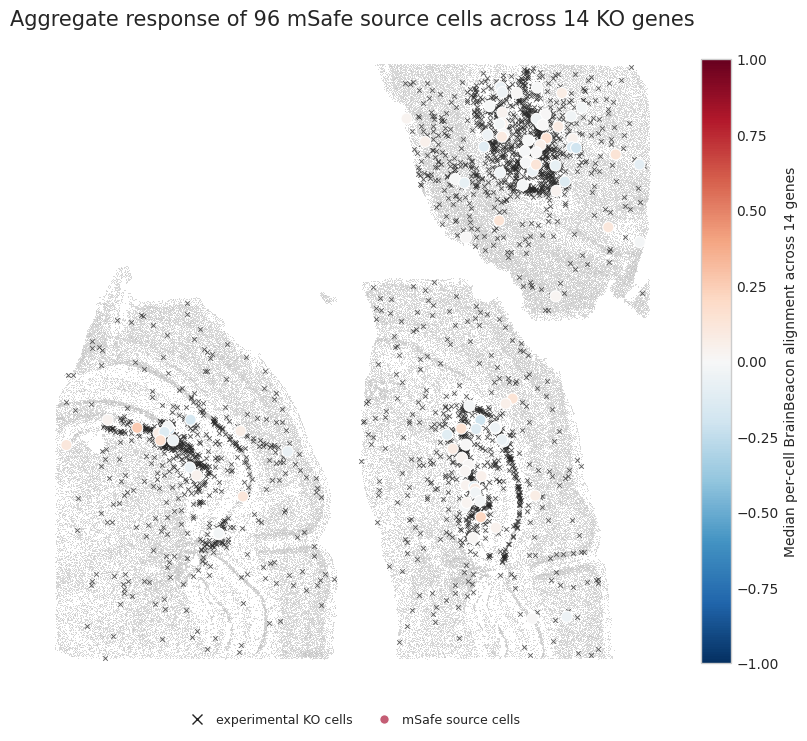

In [4]:
all_wet_mask = np.zeros(panel.n_obs, dtype=bool)
for row in selected.itertuples(index=False):
    all_wet_mask |= guide_label.eq(str(row.guide)).to_numpy()
spatial_norm = Normalize(vmin=-1, vmax=1)
spatial_cmap = plt.get_cmap('RdBu_r')
SOURCE_POINT_SIZE = 64
(fig, ax) = plt.subplots(figsize=(9.6, 7.5))
ax.scatter(coords[:, 0], coords[:, 1], s=0.55, color='#BDBDBD', alpha=0.72, linewidths=0, rasterized=True)
ax.scatter(coords[all_wet_mask, 0], coords[all_wet_mask, 1], s=11, marker='x', color='#252525', alpha=0.72, linewidths=0.65, zorder=3, rasterized=True)
aggregate_scatter = ax.scatter(source_summary['x'], source_summary['y'], s=SOURCE_POINT_SIZE, c=source_summary['median_bb_alignment'], cmap=spatial_cmap, norm=spatial_norm, edgecolors='white', linewidths=0.75, zorder=4)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.axis('off')
ax.set_title('Aggregate response of 96 mSafe source cells across 14 KO genes', fontsize=15)
cbar = fig.colorbar(aggregate_scatter, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label('Median per-cell BrainBeacon alignment across 14 genes')
wet_handle = Line2D([0], [0], marker='x', linestyle='none', color='#252525', markersize=7, label='experimental KO cells')
source_handle = Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='#C45D74', markeredgecolor='white', markersize=7, label='mSafe source cells')
ax.legend(handles=[wet_handle, source_handle], frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=9, ncol=2, columnspacing=1.5, handletextpad=0.5)
fig.tight_layout()
FIG_DIR = TUTORIAL / 'figures/fig5_experimental_ko'
FIG_DIR.mkdir(parents=True, exist_ok=True)
for extension in ('pdf', 'svg', 'png'):
    fig.savefig(FIG_DIR / f'Fig5_I_spatial_KO_concordance.{extension}', dpi=300, bbox_inches='tight')
plt.show()
panel.file.close()

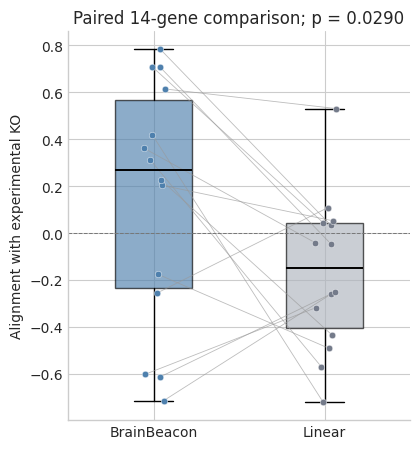

In [5]:
fig, ax = plt.subplots(figsize=(4.3, 4.6))
a = selected["bb_alignment"].to_numpy()
b = selected["linear_alignment"].to_numpy()
bp = ax.boxplot([a, b], positions=[0, 1], widths=.45, patch_artist=True, showfliers=False,
                medianprops=dict(color="black", linewidth=1.4))
for box, color in zip(bp["boxes"], ["#4e80ad", "#aeb4bd"]):
    box.set_facecolor(color); box.set_alpha(.65)
rng = np.random.default_rng(42)
jitter = rng.uniform(-.07, .07, len(a))
for i in range(len(a)):
    ax.plot([jitter[i], 1+jitter[i]], [a[i], b[i]], color="#999999", alpha=.65, lw=.6)
ax.scatter(jitter, a, s=22, c="#4e80ad", edgecolor="white", linewidth=.3, zorder=3)
ax.scatter(1+jitter, b, s=22, c="#747b8a", edgecolor="white", linewidth=.3, zorder=3)
ax.axhline(0, color="#777777", ls="--", lw=.7)
ax.set(xticks=[0,1], xticklabels=["BrainBeacon", "Linear"],
       ylabel="Alignment with experimental KO", title=f"Paired 14-gene comparison; p = {group_test.pvalue:.4f}")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
for extension in ("pdf", "svg", "png"):
    fig.savefig(FIG_DIR / f"Fig5_J_paired_KO_alignment.{extension}", dpi=300, bbox_inches="tight")
selected.to_csv(OUTPUT_DIR / "Fig5_J_gene_alignment.csv", index=False)
plt.show()

## 2. Fit the fixed Sh3gl2 ROI and calculate virtual knockout

In [6]:
import gc
import json
import os
import sys
import warnings
from pathlib import Path
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['BRAINBEACON_SKIP_X_PRED'] = '1'
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from scipy import sparse
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr, wilcoxon
from sklearn.decomposition import PCA
ROOT = Path('/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from brainbeacon.pipeline.cell_embedding import run_brainbeacon_pipeline
from brainbeacon.pipeline.perturbation import apply_gene_perturbation
from brainbeacon.tokenizer import set_seed
warnings.filterwarnings('ignore')
set_seed(42)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda:0


In [7]:
NOTEBOOK_STEM = '01_Shen_Clu_CA3like_ROI'
INPUT_DIR = ROOT / 'downstream_tasks/KO_public_dataset/inputs' / NOTEBOOK_STEM
OUTPUT_ROOT = TUTORIAL / 'outputs/fig5_experimental_ko'
RUN_DIR = OUTPUT_ROOT / 'sh3gl2_pair4_r1050_local_roi_fit100'
RUN_DIR.mkdir(parents=True, exist_ok=True)
PANEL_PATH = INPUT_DIR / 'panel_input.h5ad'
LINEAR_INPUT_PATH = INPUT_DIR / 'linear_training_inputs.npz'
PANEL_MANIFEST = json.loads((INPUT_DIR / 'input_manifest.json').read_text())
TARGET = 'Sh3gl2'
TARGET_ID = 'ENSMUSG00000028488'
GUIDE = 'sgrna_sh3gl2'
SOURCE_CONTROL_LABEL = 'sgrna_msafe'
NICHE_CONTROL_LABEL = 'Neg'
SELECTED_PAIR_ID = 4
SOURCE_OBS_NAME = 'GSM9659883_B03018A2::cell_65611'
WET_OBS_NAME = 'GSM9659883_B03018A2::cell_75597'
ROI_CENTER = np.asarray([17867.909090909092, 13285.5], dtype=float)
ROI_RADIUS = 1050.0
NICHE_BREADTH = 45
NICHE_K = 10
FIT_EPOCHS = 100
FORCE_REFIT_BASELINE = os.environ.get('BB_FORCE_REFIT_BASELINE', '1') == '1'
RERUN_FROZEN_INFERENCE = os.environ.get('BB_RERUN_FROZEN_INFERENCE', '1') == '1'
LINEAR_K = 10
RIDGE_LAMBDA = 0.1
STAGE1_CKPT = ROOT / 'prior_knowledge/ABL1_full_final_epoch_0_step_10000.pt'
BASE_STAGE2_CKPT = ROOT / 'prior_knowledge/stage2_epoch280_fit200.pt'
GENE_DICT = Path(PANEL_MANIFEST['gene_dict'])
FITTED_CHECKPOINT = RUN_DIR / 'stage2_sh3gl2_pair4_r1050_fit100.pt'
BASELINE_CACHE = RUN_DIR / 'baseline_local_roi_x_emb.npz'
VIRTUAL_CACHE = RUN_DIR / 'sh3gl2_virtual_ko_local_roi_x_emb.npz'
LINEAR_CACHE = RUN_DIR / 'sh3gl2_linear_local_roi_x_emb.npz'
ROI_INPUT_PATH = RUN_DIR / 'sh3gl2_pair4_r1050_unmodified_roi.h5ad'
STAGE1_CONFIG = {'dim_model': 1024, 'dim_feedforward': 1024, 'nheads': 16, 'nlayers': 16, 'n_connect_comp': 46714, 'use_esm_emb': True, 'use_gene_id_emb': True, 'use_homo_emb': True, 'use_rna_type_emb': True, 'use_gene_deviation': True, 'use_cell_density': True, 'use_dev_abs': True, 'esm_emb_dim': 5120, 'species': True, 'assay': True, 'n_hvg': 5000, 'hvg_log1p': True, 'cd_weight': 0.02, 'use_hvg': False, 'weight_mode': 'expression', 'force_tokenize': True, 'use_mean_norm': True}
STAGE2_CONFIG = {'sampling_mode': 'spatial', 'use_patch': False, 'eval_use_patch': False, 'max_eval_batch_size': 50000, 'pe_weight': 1.0}
print('target:', TARGET, TARGET_ID)
print('fixed source/wet pair:', SOURCE_OBS_NAME, WET_OBS_NAME)
print('fixed ROI center/radius:', ROI_CENTER, ROI_RADIUS)
print('run directory:', RUN_DIR)

target: Sh3gl2 ENSMUSG00000028488
fixed source/wet pair: GSM9659883_B03018A2::cell_65611 GSM9659883_B03018A2::cell_75597
fixed ROI center/radius: [17867.90909091 13285.5       ] 1050.0
run directory: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100


### Load the unmodified ROI

In [8]:
adata_full = sc.read_h5ad(PANEL_PATH)
coords_full = np.asarray(adata_full.obsm['spatial'], dtype=float)
distance_to_center = np.linalg.norm(coords_full - ROI_CENTER[None, :], axis=1)
roi_mask = distance_to_center <= ROI_RADIUS
adata_roi = adata_full[roi_mask].copy()
adata_roi.obs['split'] = 'train'
coords = np.asarray(adata_roi.obsm['spatial'], dtype=float)
roi_lookup = {name: index for (index, name) in enumerate(adata_roi.obs_names.astype(str))}
source = int(roi_lookup[SOURCE_OBS_NAME])
wet = int(roi_lookup[WET_OBS_NAME])
source_idx = np.asarray([source], dtype=int)
target_col = int(adata_roi.var_names.get_loc(TARGET_ID))
guide = adata_roi.obs['guide_label'].astype(str).to_numpy()

def dense_values(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)
source_target_count = float(dense_values(adata_roi.X[source, target_col]).ravel()[0])
wet_target_count = float(dense_values(adata_roi.X[wet, target_col]).ravel()[0])
source_total = float(dense_values(adata_roi.X[source]).sum())
wet_total = float(dense_values(adata_roi.X[wet]).sum())
source_target_cpm = 1000000.0 * source_target_count / max(source_total, 1.0)
wet_target_cpm = 1000000.0 * wet_target_count / max(wet_total, 1.0)
adata_roi.obs['local_roi_role'] = 'background'
adata_roi.obs.loc[SOURCE_OBS_NAME, 'local_roi_role'] = 'virtual_source'
adata_roi.obs.loc[WET_OBS_NAME, 'local_roi_role'] = 'wet_Sh3gl2_KO'
roi_contract = pd.DataFrame([{'target': TARGET, 'target_id': TARGET_ID, 'guide': GUIDE, 'pair_id': SELECTED_PAIR_ID, 'center_x': ROI_CENTER[0], 'center_y': ROI_CENTER[1], 'radius': ROI_RADIUS, 'n_full_slice_cells': adata_full.n_obs, 'n_roi_cells': adata_roi.n_obs, 'source_obs_name': SOURCE_OBS_NAME, 'wet_obs_name': WET_OBS_NAME, 'source_target_count': source_target_count, 'wet_target_count': wet_target_count, 'source_target_cpm': source_target_cpm, 'wet_target_cpm': wet_target_cpm, 'selection_basis': 'best strict-positive gene-level case in the fixed ROI screen'}])
roi_contract.to_csv(RUN_DIR / 'sh3gl2_pair4_r1050_roi_contract.tsv', sep='\t', index=False)
display(roi_contract.T)
print('full slice:', adata_full.shape)
print('model input ROI:', adata_roi.shape)

,0
target,Sh3gl2
target_id,ENSMUSG00000028488
guide,sgrna_sh3gl2
pair_id,4
center_x,17867.909091
center_y,13285.5
radius,1050.0
n_full_slice_cells,40940
n_roi_cells,1334
source_obs_name,GSM9659883_B03018A2::cell_65611


full slice: (40940, 24347)
model input ROI: (1334, 24347)


### Inspect the fixed source and wet KO pair

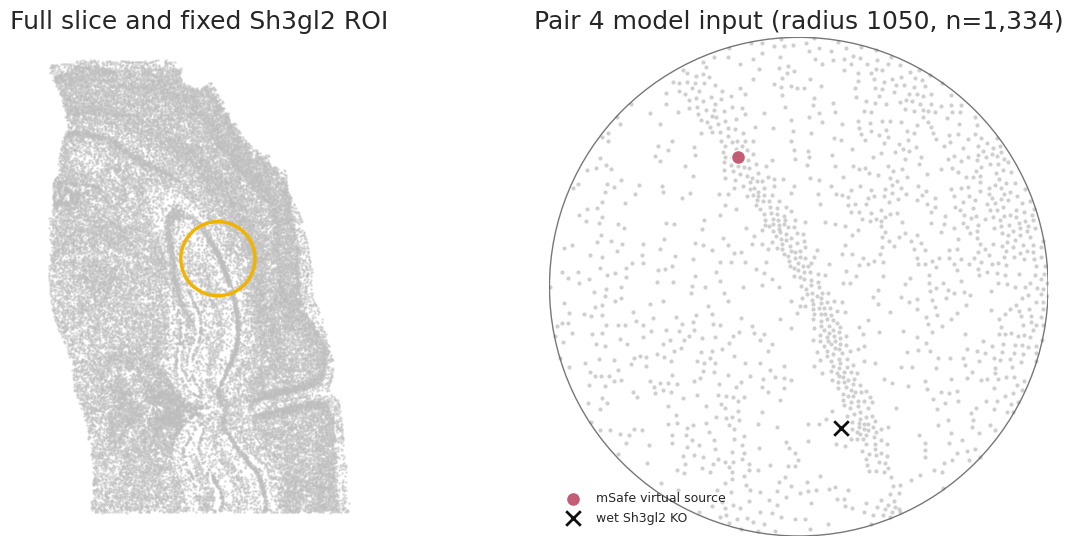

/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/sh3gl2_pair4_roi_selection.png
/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/sh3gl2_pair4_roi_selection.pdf


In [9]:
def style_roi_axis(ax):
    ax.set_xlim(ROI_CENTER[0] - ROI_RADIUS, ROI_CENTER[0] + ROI_RADIUS)
    ax.set_ylim(ROI_CENTER[1] + ROI_RADIUS, ROI_CENTER[1] - ROI_RADIUS)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.add_patch(Circle(tuple(ROI_CENTER), ROI_RADIUS, fill=False, edgecolor='#555555', linewidth=1.0, alpha=0.8))
(fig, axes) = plt.subplots(1, 2, figsize=(13.2, 5.8))
axes[0].scatter(coords_full[:, 0], coords_full[:, 1], s=3, c='#bdbdbd', alpha=0.58, linewidths=0, rasterized=True)
axes[0].add_patch(Circle(tuple(ROI_CENTER), ROI_RADIUS, fill=False, edgecolor='#f0b400', linewidth=2.5))
axes[0].set_title('Full slice and fixed Sh3gl2 ROI')
axes[0].set_aspect('equal')
axes[0].invert_yaxis()
axes[0].axis('off')
axes[1].scatter(coords[:, 0], coords[:, 1], s=9, c='#bdbdbd', alpha=0.72, linewidths=0, rasterized=True)
axes[1].scatter(coords[source, 0], coords[source, 1], s=100, c='#c45d74', edgecolors='white', linewidths=0.9, label='mSafe virtual source')
axes[1].scatter(coords[wet, 0], coords[wet, 1], s=110, c='#111111', marker='x', linewidths=2.0, label='wet Sh3gl2 KO')
style_roi_axis(axes[1])
axes[1].set_title(f'Pair 4 model input (radius 1050, n={adata_roi.n_obs:,})')
axes[1].legend(frameon=False, fontsize=9, loc='best')
fig.tight_layout()
roi_selection_png = RUN_DIR / 'sh3gl2_pair4_roi_selection.png'
roi_selection_pdf = roi_selection_png.with_suffix('.pdf')
fig.savefig(roi_selection_png, dpi=300, bbox_inches='tight')
fig.savefig(roi_selection_pdf, bbox_inches='tight')
plt.show()
print(roi_selection_png)
print(roi_selection_pdf)

### Match 10 local Neg controls using spatial distance

In [10]:
neg_pool = np.flatnonzero(guide == NICHE_CONTROL_LABEL)

def distance_only_niche_match(anchor_a, anchor_b, k=NICHE_K):
    pool = neg_pool[(neg_pool != int(anchor_a)) & (neg_pool != int(anchor_b))]

    def nearest(anchor):
        radius = np.linalg.norm(coords[pool] - coords[int(anchor)], axis=1)
        order = np.argsort(radius, kind='stable')[:min(NICHE_BREADTH, len(pool))]
        return (pool[order], radius[order])
    (candidates_a, radius_a) = nearest(anchor_a)
    (candidates_b, radius_b) = nearest(anchor_b)
    scale = max(float(np.median(np.r_[radius_a, radius_b])), 1.0)
    total_cost = np.abs(radius_a[:, None] - radius_b[None, :]) / scale
    total_cost += 1000000.0 * (candidates_a[:, None] == candidates_b[None, :])
    (rows, columns) = linear_sum_assignment(total_cost)
    order = np.argsort(total_cost[rows, columns], kind='stable')
    selected = order[:min(int(k), len(order))]
    return {'source_selected': candidates_a[rows[selected]], 'wet_selected': candidates_b[columns[selected]], 'source_candidates': candidates_a, 'wet_candidates': candidates_b, 'source_radius': radius_a, 'wet_radius': radius_b, 'rows': rows, 'columns': columns, 'order': order, 'cost': total_cost}
niche_match = distance_only_niche_match(source, wet)
source_niche_idx = niche_match['source_selected'].astype(int)
wet_niche_idx = niche_match['wet_selected'].astype(int)
source_niche_names = adata_roi.obs_names[source_niche_idx].astype(str).tolist()
wet_niche_names = adata_roi.obs_names[wet_niche_idx].astype(str).tolist()
adata_roi.obs.loc[source_niche_names, 'local_roi_role'] = 'virtual_niche'
adata_roi.obs.loc[wet_niche_names, 'local_roi_role'] = 'wet_niche'
adata_roi.write(ROI_INPUT_PATH)
rows = niche_match['rows']
columns = niche_match['columns']
order = niche_match['order']
source_candidates = niche_match['source_candidates']
wet_candidates = niche_match['wet_candidates']
source_radius = niche_match['source_radius']
wet_radius = niche_match['wet_radius']
cost = niche_match['cost']
assignment = pd.DataFrame({'assignment_rank': np.arange(1, len(order) + 1), 'source_obs_name': adata_roi.obs_names[source_candidates[rows[order]]].astype(str), 'wet_obs_name': adata_roi.obs_names[wet_candidates[columns[order]]].astype(str), 'source_radius': source_radius[rows[order]], 'wet_radius': wet_radius[columns[order]], 'normalized_radius_cost': cost[rows[order], columns[order]]})
assignment['selected'] = assignment['assignment_rank'] <= NICHE_K
assignment['reason'] = np.where(assignment['selected'], 'selected: one of 10 lowest radial-matching costs', 'not selected: radial-matching cost rank > 10')
assignment.to_csv(RUN_DIR / 'sh3gl2_distance_only_niche_assignment.tsv', sep='\t', index=False)
display(assignment.head(15))

,assignment_rank,source_obs_name,wet_obs_name,source_radius,wet_radius,normalized_radius_cost,selected,reason
0,1,GSM9659883_B03018A2::cell_65600,GSM9659883_B03018A2::cell_75591,66.468037,65.734314,0.004394,True,selected: one of 10 lowest radial-matching costs
1,2,GSM9659883_B03018A2::cell_67471,GSM9659883_B03018A2::cell_73444,143.377125,141.014184,0.014152,True,selected: one of 10 lowest radial-matching costs
2,3,GSM9659883_B03018A2::cell_65625,GSM9659883_B03018A2::cell_75596,82.036577,78.447435,0.021496,True,selected: one of 10 lowest radial-matching costs
3,4,GSM9659883_B03018A2::cell_65601,GSM9659883_B03018A2::cell_75592,44.922155,51.884487,0.041698,True,selected: one of 10 lowest radial-matching costs
4,5,GSM9659883_B03018A2::cell_65658,GSM9659883_B03018A2::cell_75586,93.380940,83.815273,0.057290,True,selected: one of 10 lowest radial-matching costs
5,6,GSM9659883_B03018A2::cell_65602,GSM9659883_B03018A2::cell_75594,49.040799,60.207973,0.066882,True,selected: one of 10 lowest radial-matching costs
6,7,GSM9659883_B03018A2::cell_65604,GSM9659883_B03018A2::cell_75613,182.321145,169.011834,0.079711,True,selected: one of 10 lowest radial-matching costs
7,8,GSM9659883_B03018A2::cell_65616,GSM9659883_B03018A2::cell_75593,25.019992,43.185646,0.108796,True,selected: one of 10 lowest radial-matching costs
8,9,GSM9659883_B03018A2::cell_67489,GSM9659883_B03018A2::cell_73445,205.769288,186.657440,0.114463,True,selected: one of 10 lowest radial-matching costs
9,10,GSM9659883_B03018A2::cell_67482,GSM9659883_B03018A2::cell_75561,161.297861,141.152400,0.120654,True,selected: one of 10 lowest radial-matching costs


### Fit the baseline model for 100 epochs

In [11]:
gene_dict_obj = ad.read_h5ad(GENE_DICT, backed='r')
token_present = TARGET_ID in gene_dict_obj.obs_names.astype(str) or TARGET_ID in gene_dict_obj.var_names.astype(str)
gene_dict_obj.file.close()

def save_embedding_cache(path, embedding, adata_obj):
    np.savez_compressed(path, X_emb=np.asarray(embedding, dtype=np.float32), obs_names=adata_obj.obs_names.astype(str).to_numpy())

def load_embedding_cache(path, adata_obj):
    payload = np.load(path, allow_pickle=True)
    expected = adata_obj.obs_names.astype(str).to_numpy()
    return payload['X_emb'].astype(np.float32)
cache_ready = FITTED_CHECKPOINT.exists() and BASELINE_CACHE.exists()
if cache_ready and (not FORCE_REFIT_BASELINE):
    baseline = load_embedding_cache(BASELINE_CACHE, adata_roi)
else:
    baseline_result = run_brainbeacon_pipeline(adata=adata_roi, species='mouse', assay='stereo', gene_dict_path=str(GENE_DICT), stage1_ckpt_path=str(STAGE1_CKPT), stage2_ckpt_path=str(BASE_STAGE2_CKPT), output_dir=str(RUN_DIR / 'baseline_pipeline'), output_prefix='Shen_Sh3gl2_pair4_r1050_baseline_fit100', stage1_config=dict(STAGE1_CONFIG), stage2_config=dict(STAGE2_CONFIG), do_fit=True, fit_epochs=FIT_EPOCHS, save_model=True, save_model_path=str(FITTED_CHECKPOINT), device=device, seed=42, deterministic=True)
    baseline = np.asarray(baseline_result.obsm['X_emb'], dtype=np.float32)
    save_embedding_cache(BASELINE_CACHE, baseline, adata_roi)
    del baseline_result
    gc.collect()
    torch.cuda.empty_cache()
print('target admitted to gene dictionary:', token_present)
print('baseline embedding:', baseline.shape)
print('fitted checkpoint:', FITTED_CHECKPOINT)

====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...


Computing cell density...
compute_density_token time: 0.0052 seconds


[Stage1 memory] Tokenization done: 1334 cells, 20.5s


[Stage1 memory] Running inference (batch_size=64)...


Loaded pretrain_model checkpoint (strict): /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/prior_knowledge/ABL1_full_final_epoch_0_step_10000.pt


...

100%|██████████| 100/100 [01:10<00:00,  1.45it/s]

100%|██████████| 100/100 [01:10<00:00,  1.42it/s]

Epoch 99 | Train loss: 3499.9590 | Valid loss: 3434.6748
After filtering, 24347 genes remain.


Model saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/stage2_sh3gl2_pair4_r1050_fit100.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/baseline_pipeline/Shen_Sh3gl2_pair4_r1050_baseline_fit100_stage2_embeddings.npz


target admitted to gene dictionary: True
baseline embedding: (1334, 512)
fitted checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/stage2_sh3gl2_pair4_r1050_fit100.pt


### Knock out Sh3gl2 and infer with the fitted model

In [12]:
(virtual_input, perturbed_cells) = apply_gene_perturbation(adata=adata_roi, gene_list=[TARGET_ID], mode='knockout', target_obs_names=[SOURCE_OBS_NAME], knockout_only_expressed=False, verbose=True)
before = dense_values(adata_roi.X[source_idx, target_col]).ravel()
after = dense_values(virtual_input.X[source_idx, target_col]).ravel()
if VIRTUAL_CACHE.exists() and (not RERUN_FROZEN_INFERENCE):
    virtual = load_embedding_cache(VIRTUAL_CACHE, adata_roi)
else:
    virtual_result = run_brainbeacon_pipeline(adata=virtual_input, species='mouse', assay='stereo', gene_dict_path=str(GENE_DICT), stage1_ckpt_path=str(STAGE1_CKPT), stage2_ckpt_path=str(FITTED_CHECKPOINT), output_dir=str(RUN_DIR / 'virtual_ko_pipeline'), output_prefix='Shen_Sh3gl2_pair4_r1050_virtual_KO', stage1_config=dict(STAGE1_CONFIG), stage2_config=dict(STAGE2_CONFIG), do_fit=False, fit_epochs=0, save_model=False, device=device, seed=42, deterministic=True)
    virtual = np.asarray(virtual_result.obsm['X_emb'], dtype=np.float32)
    save_embedding_cache(VIRTUAL_CACHE, virtual, adata_roi)
    del virtual_result
    gc.collect()
    torch.cuda.empty_cache()
del virtual_input
gc.collect()
torch.cuda.empty_cache()
print('Sh3gl2 before/after KO:', before[0], after[0])
print('virtual embedding:', virtual.shape)

========== apply_gene_perturbation ==========
mode: knockout
genes input: ['ENSMUSG00000028488']
genes resolved: ['ENSMUSG00000028488']
adata.n_vars: 24347
candidate cells before perturb expression filter: 1
knockout_only_expressed: False
knockout_expr_threshold: auto
knockout_var_cutoff: 1000
knockout_high_var_threshold: 5.0
effective KO threshold: 5.0
perturbed cells: 1
random_state: 0
====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...
Computing cell density...
compute_density_token time: 0.0045 seconds


[Stage1 memory] Tokenization done: 1334 cells, 14.0s
[Stage1 memory] Running inference (batch_size=64)...


Loaded pretrain_model checkpoint (strict): /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/prior_knowledge/ABL1_full_final_epoch_0_step_10000.pt


[Stage1 memory] Inference:   0%|          | 0/21 [00:00<?, ?it/s]

[Stage1 memory] Inference:   5%|▍         | 1/21 [00:00<00:12,  1.62it/s]

...

[INFO] Loading stage2 pretrained checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/stage2_sh3gl2_pair4_r1050_fit100.pt


[INFO] Skipped parameters (0): []


After filtering, 24347 genes remain.


Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/virtual_ko_pipeline/Shen_Sh3gl2_pair4_r1050_virtual_KO_stage2_embeddings.npz


Sh3gl2 before/after KO: 2.0 0.0
virtual embedding: (1334, 512)


### Fit the manuscript Linear comparator
Read the original Clu-held-out training matrix, refit PCA and ridge regression, and apply the predicted full-gene expression change to the Sh3gl2 source cell. Run frozen inference with the baseline fitted above. The training matrix includes Sh3gl2, matching the original figure script.

In [13]:
linear_inputs = np.load(LINEAR_INPUT_PATH)
y_delta = linear_inputs['y_delta'].astype(np.float32)
perturb_gene_indices = linear_inputs['perturb_gene_indices'].astype(int)

def fit_linear_delta(y_delta_matrix, perturb_indices, target_gene_index):
    k_eff = min(LINEAR_K, y_delta_matrix.shape[1] - 1, y_delta_matrix.shape[0] - 1)
    gene_embedding = PCA(n_components=k_eff, random_state=42).fit_transform(y_delta_matrix).astype(np.float64)
    perturb_embedding = gene_embedding[np.asarray(perturb_indices, dtype=int)]
    left_ridge = gene_embedding.T @ gene_embedding + RIDGE_LAMBDA * np.eye(k_eff)
    right_ridge = perturb_embedding.T @ perturb_embedding + RIDGE_LAMBDA * np.eye(k_eff)
    left = np.linalg.solve(left_ridge, gene_embedding.T @ y_delta_matrix @ perturb_embedding)
    weight = np.linalg.solve(right_ridge.T, left.T).T
    predicted = gene_embedding @ weight @ gene_embedding[int(target_gene_index)]
    return (predicted.astype(np.float32), k_eff)
(predicted_delta, linear_k_eff) = fit_linear_delta(y_delta, perturb_gene_indices, target_col)
linear_input = adata_roi.copy()
source_expression = dense_values(linear_input.X[source_idx]).astype(np.float32)
shifted_expression = np.clip(source_expression + predicted_delta[None, :], 0.0, None)
if sparse.issparse(linear_input.X):
    changed = linear_input.X.tolil(copy=True)
    values = shifted_expression[0]
    nonzero = np.flatnonzero(values > 1e-12)
    changed.rows[source] = nonzero.tolist()
    changed.data[source] = values[nonzero].tolist()
    linear_input.X = changed.tocsr()
else:
    linear_input.X[source, :] = shifted_expression
if LINEAR_CACHE.exists() and (not RERUN_FROZEN_INFERENCE):
    linear_embedding = load_embedding_cache(LINEAR_CACHE, adata_roi)
else:
    linear_result = run_brainbeacon_pipeline(adata=linear_input, species='mouse', assay='stereo', gene_dict_path=str(GENE_DICT), stage1_ckpt_path=str(STAGE1_CKPT), stage2_ckpt_path=str(FITTED_CHECKPOINT), output_dir=str(RUN_DIR / 'linear_target_pipeline'), output_prefix='Shen_Sh3gl2_pair4_r1050_linear_target', stage1_config=dict(STAGE1_CONFIG), stage2_config=dict(STAGE2_CONFIG), do_fit=False, fit_epochs=0, save_model=False, device=device, seed=42, deterministic=True)
    linear_embedding = np.asarray(linear_result.obsm['X_emb'], dtype=np.float32)
    save_embedding_cache(LINEAR_CACHE, linear_embedding, adata_roi)
    del linear_result
    gc.collect()
    torch.cuda.empty_cache()
del linear_input
gc.collect()
torch.cuda.empty_cache()
print('linear training matrix:', y_delta.shape)
print('linear k_eff:', linear_k_eff)
linear_training = pd.DataFrame({
    "training_target": adata_full.var.iloc[perturb_gene_indices]["gene_symbol"].astype(str).to_numpy(),
    "gene_index": perturb_gene_indices,
    "held_out_target": "Clu",
})
linear_training.to_csv(RUN_DIR / "linear_training_guides.tsv", sep="\t", index=False)
np.savez_compressed(RUN_DIR / "linear_training_inputs.npz", y_delta=y_delta,
                    perturb_gene_indices=perturb_gene_indices, predicted_delta=predicted_delta)
display(linear_training)


====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...


Computing cell density...
compute_density_token time: 0.0071 seconds


[Stage1 memory] Tokenization done: 1334 cells, 16.6s
[Stage1 memory] Running inference (batch_size=64)...


Loaded pretrain_model checkpoint (strict): /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/prior_knowledge/ABL1_full_final_epoch_0_step_10000.pt


[Stage1 memory] Inference:   0%|          | 0/21 [00:00<?, ?it/s]

...

[INFO] Skipped parameters (0): []


After filtering, 24347 genes remain.


Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_ko/sh3gl2_pair4_r1050_local_roi_fit100/linear_target_pipeline/Shen_Sh3gl2_pair4_r1050_linear_target_stage2_embeddings.npz


linear training matrix: (24347, 16)
linear k_eff: 10


,training_target,gene_index,held_out_target
0,Fasn,6862,Clu
1,Olig2,16861,Clu
2,Stk39,21228,Clu
3,Trem2,22493,Clu
4,Sh3gl2,20035,Clu
5,Flcn,7108,Clu
6,Gfap,7531,Clu
7,Rraga,19431,Clu
8,Cfap410,4304,Clu
9,Ndufaf2,16207,Clu


### Calculate target and context alignment

In [14]:
def cosine(left, right):
    left = np.asarray(left, dtype=float).ravel()
    right = np.asarray(right, dtype=float).ravel()
    denominator = np.linalg.norm(left) * np.linalg.norm(right)
    if denominator <= 1e-12:
        return np.nan
    return float(np.dot(left, right) / denominator)
wet_target_delta = baseline[wet] - baseline[source]
bb_target_delta = virtual[source] - baseline[source]
linear_target_delta = linear_embedding[source] - baseline[source]
wet_niche_pair_delta = baseline[wet_niche_idx] - baseline[source_niche_idx]
wet_niche_delta = np.mean(wet_niche_pair_delta, axis=0)
bb_niche_delta = np.mean(virtual[source_niche_idx] - baseline[source_niche_idx], axis=0)
bb_target_alignment = cosine(bb_target_delta, wet_target_delta)
linear_target_alignment = cosine(linear_target_delta, wet_target_delta)
bb_niche_alignment = cosine(bb_niche_delta, wet_niche_delta)
strict_pass = bool(bb_target_alignment > 0 and bb_target_alignment > linear_target_alignment and (bb_niche_alignment > 0))
metrics = pd.DataFrame([{'target': TARGET, 'pair_id': SELECTED_PAIR_ID, 'radius': ROI_RADIUS, 'BB target': bb_target_alignment, 'Linear target': linear_target_alignment, 'BB niche': bb_niche_alignment, 'BB target > 0': bb_target_alignment > 0, 'BB target > Linear': bb_target_alignment > linear_target_alignment, 'BB niche > 0': bb_niche_alignment > 0, 'strict_pass': strict_pass, 'n_independent_pairs': 1, 'inferential_p_value': np.nan}])
metrics.to_csv(RUN_DIR / 'sh3gl2_pair4_alignment_metrics.tsv', sep='\t', index=False)
display(metrics)
print('Single selected ROI: metrics are descriptive, not an independent-replicate test.')

,target,pair_id,radius,BB target,Linear target,BB niche,BB target > 0,BB target > Linear,BB niche > 0,strict_pass,n_independent_pairs,inferential_p_value
0,Sh3gl2,4,1050.0,0.538048,-0.123943,0.360784,True,True,True,True,1,NaN


Single selected ROI: metrics are descriptive, not an independent-replicate test.


### Visualize the local validation results

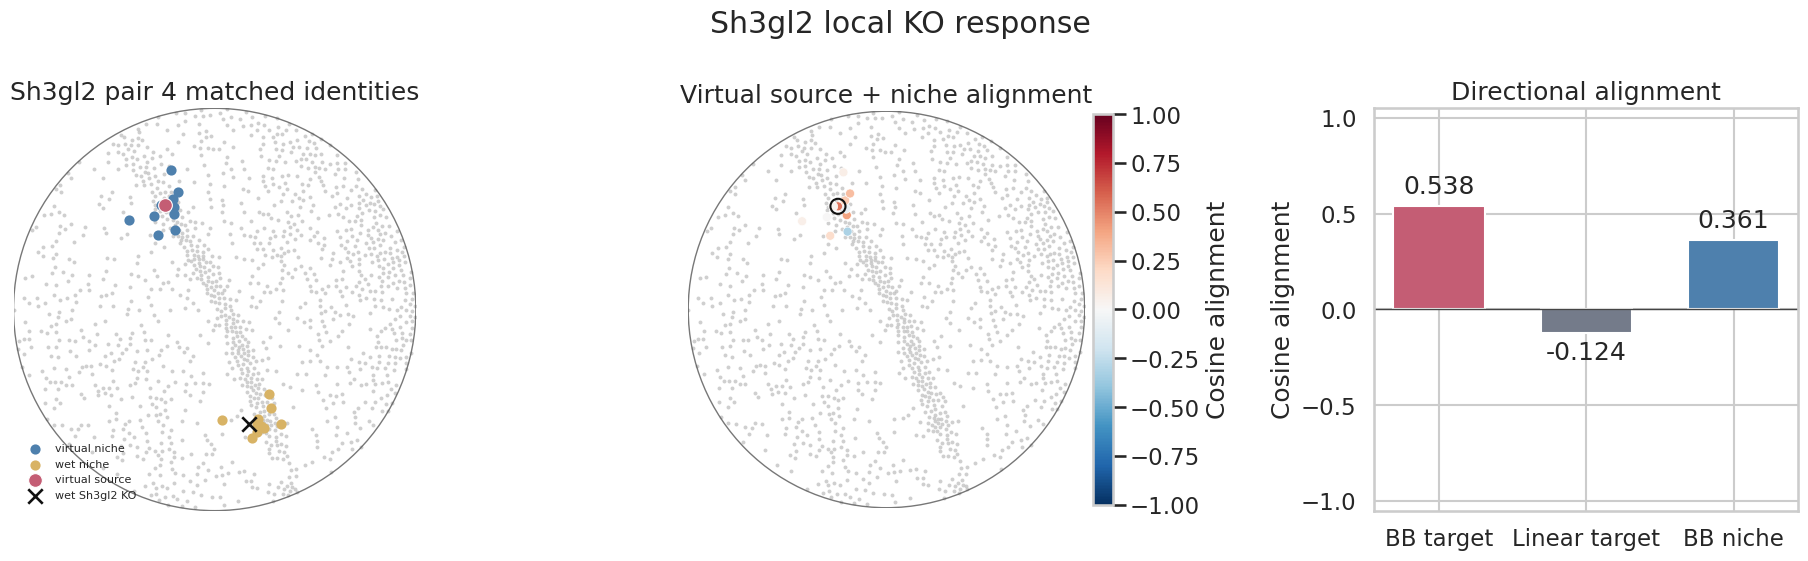

In [15]:
display_alignment = np.full(adata_roi.n_obs, np.nan)
display_alignment[source] = bb_target_alignment
for (source_neighbor, wet_neighbor) in zip(source_niche_idx, wet_niche_idx):
    display_alignment[source_neighbor] = cosine(virtual[source_neighbor] - baseline[source_neighbor], baseline[wet_neighbor] - baseline[source_neighbor])
colored = np.flatnonzero(np.isfinite(display_alignment))
(fig, axes) = plt.subplots(1, 3, figsize=(18.5, 5.8))
axes[0].scatter(coords[:, 0], coords[:, 1], s=8, c='#bdbdbd', alpha=0.72, linewidths=0, rasterized=True)
axes[0].scatter(coords[source_niche_idx, 0], coords[source_niche_idx, 1], s=34, c='#4e80ad', label='virtual niche')
axes[0].scatter(coords[wet_niche_idx, 0], coords[wet_niche_idx, 1], s=34, c='#d8b365', label='wet niche')
axes[0].scatter(coords[source, 0], coords[source, 1], s=98, c='#c45d74', edgecolors='white', linewidths=0.8, label='virtual source')
axes[0].scatter(coords[wet, 0], coords[wet, 1], s=108, c='#111111', marker='x', linewidths=1.9, label='wet Sh3gl2 KO')
style_roi_axis(axes[0])
axes[0].set_title('Sh3gl2 pair 4 matched identities')
axes[0].legend(frameon=False, fontsize=8)
axes[1].scatter(coords[:, 0], coords[:, 1], s=8, c='#bdbdbd', alpha=0.72, linewidths=0, rasterized=True)
alignment_map = axes[1].scatter(coords[colored, 0], coords[colored, 1], s=42, c=display_alignment[colored], cmap='RdBu_r', vmin=-1, vmax=1, edgecolors='white', linewidths=0.45)
axes[1].scatter(coords[source, 0], coords[source, 1], s=118, facecolors='none', edgecolors='#111111', linewidths=1.5)
style_roi_axis(axes[1])
axes[1].set_title('Virtual source + niche alignment')
fig.colorbar(alignment_map, ax=axes[1], fraction=0.046, pad=0.02, label='Cosine alignment')
labels = ['BB target', 'Linear target', 'BB niche']
values = [bb_target_alignment, linear_target_alignment, bb_niche_alignment]
bars = axes[2].bar(labels, values, color=['#c45d74', '#747b8a', '#4e80ad'], width=0.62)
axes[2].axhline(0, color='#444444', linewidth=1)
axes[2].set_ylim(-1.05, 1.05)
for (bar, value) in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, value + (0.04 if value >= 0 else -0.04), f'{value:.3f}', ha='center', va='bottom' if value >= 0 else 'top')
axes[2].set_ylabel('Cosine alignment')
axes[2].set_title('Directional alignment')
fig.suptitle('Sh3gl2 local KO response')
fig.tight_layout()
for extension in ('pdf', 'svg', 'png'):
    fig.savefig(FIG_DIR / f'Fig5_K_Sh3gl2_local_KO.{extension}', dpi=300, bbox_inches='tight')
plt.show()